# Oráculo: dealiasing de rango (ecos de trip múltiple)

Oráculo de `docs/algorithms/dealiasing-de-rango.md`, independiente de
cualquier crate Rust (todavía no existe implementación — primer paso del
método de `docs/algorithms/roadmap.md` §"Método de estudio"). Cubre los dos
peldaños que la página fija como alcance de Stage 1 — detección y marcado
(toda instalación), y recuperación por fase aleatoria (magnetrón) — y deja
SZ(8/64) donde la propia página lo deja: diferido, con página propia.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(20260916)
plt.rcParams["figure.figsize"] = (9, 4)
np.set_printoptions(precision=4, suppress=True)

In [2]:
def gaussian_doppler_spectrum(power_s, mean_v, sigma_v, wavelength_m, prt_s, m, wrap=3):
    v_a = wavelength_m / (4.0 * prt_s)
    f_k = np.fft.fftfreq(m, d=prt_s)
    v_k = f_k * wavelength_m / 2.0
    n = np.arange(-wrap, wrap + 1)
    dv = v_k[:, None] - mean_v - n[None, :] * 2.0 * v_a
    acc = np.exp(-0.5 * (dv / sigma_v) ** 2).sum(axis=1)
    return power_s * acc / acc.sum()


def complex_gaussian(rng, variance, size=None):
    sigma = np.sqrt(variance / 2.0)
    return rng.normal(0.0, sigma, size=size) + 1j * rng.normal(0.0, sigma, size=size)


def generate_signal_only(power_s, mean_v, sigma_v, wavelength_m, prt_s, m, rng, wrap=3):
    spectrum = gaussian_doppler_spectrum(power_s, mean_v, sigma_v, wavelength_m, prt_s, m, wrap)
    w = complex_gaussian(rng, 1.0, size=m)
    return np.fft.ifft(w * np.sqrt(spectrum)) * m


def periodogram_raw(y):
    m = len(y)
    yf = np.fft.fft(y)
    return (np.abs(yf) ** 2) / (m ** 2)


def hildebrand_sekhon(p, navg=1):
    p_sorted = np.sort(p)
    n = len(p_sorted)
    rtest = 1.0 + 1.0 / navg
    nnoise = n
    sum1 = 0.0
    sum2 = 0.0
    for i in range(n):
        pwr = p_sorted[i]
        npts = i + 1
        sum1 += pwr
        sum2 += pwr * pwr
        if npts * sum2 < sum1 * sum1 * rtest:
            nnoise = npts
        else:
            sum1 -= pwr
            sum2 -= pwr * pwr
            break
    return sum1 / nnoise


def noise_floor_estimate(y):
    return hildebrand_sekhon(periodogram_raw(y)) * len(y)


def pulse_pair_velocity(y, wavelength_m, prt_s):
    r1 = np.mean(y[:-1] * np.conj(y[1:]))
    return -wavelength_m / (4.0 * np.pi * prt_s) * np.angle(r1)


checks = []

## Prueba 1 — detección y marcado por comparación dual-PRF

Un eco de primer trip aparece en la misma posición con las dos PRFs; uno de
trip superior se desplaza, porque `r_max` es distinto en cada una. Para una
celda dada en el barrido de PRF alta (`r_max` corto, el que sufre
solapamiento), se prueban las dos hipótesis —trip1: rango verdadero = la
posición aparente; trip2: rango verdadero = posición aparente + `r_max`
corto— y se elige la que reconcilia con la posición leída en el barrido de
PRF baja (`r_max` largo, sin plegar a estos rangos).

**Modelo de detección, declarado como ilustrativo.** La probabilidad de
detectar el eco en cada barrido se modela con una curva logística en
función de la SNR — una elección razonable para mostrar degradación suave,
no una calibración de ningún radar real; el contrato no fija esa curva y
ninguna página de este conjunto la especifica.

r_max (PRF baja) = 150.0 km   r_max (PRF alta) = 90.0 km
SNR= -2.0 dB  trip1 correcto=7.75%  trip2 detectado=0.25%
SNR=  0.0 dB  trip1 correcto=21.00%  trip2 detectado=3.75%
SNR=  2.0 dB  trip1 correcto=37.50%  trip2 detectado=13.25%
SNR=  4.0 dB  trip1 correcto=64.25%  trip2 detectado=43.75%
SNR=  6.0 dB  trip1 correcto=83.00%  trip2 detectado=69.25%
SNR= 10.0 dB  trip1 correcto=97.25%  trip2 detectado=95.00%
SNR= 15.0 dB  trip1 correcto=99.50%  trip2 detectado=100.00%


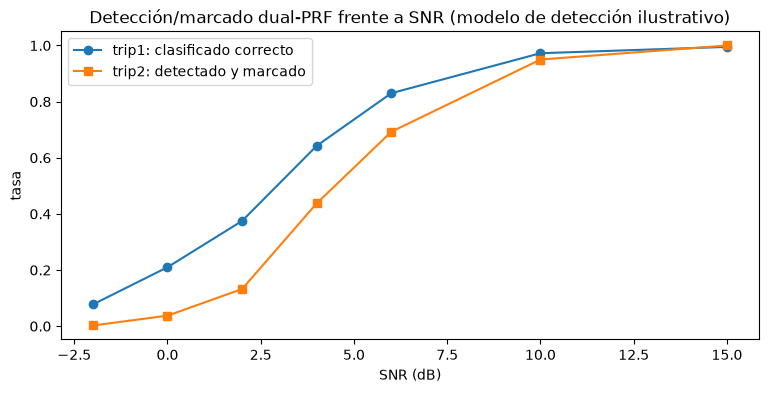

In [3]:
C_LIGHT = 3.0e8
PRT_LOW, PRT_HIGH = 1.0e-3, 0.6e-3  # PRF baja: r_max largo: PRF alta: r_max corto, sufre solapamiento
R_MAX_LOW = C_LIGHT * PRT_LOW / 2.0
R_MAX_HIGH = C_LIGHT * PRT_HIGH / 2.0
GATE_SPACING_M = 250.0
print(f"r_max (PRF baja) = {R_MAX_LOW/1000:.1f} km   r_max (PRF alta) = {R_MAX_HIGH/1000:.1f} km")


def detect_probability(snr_db):
    return 1.0 / (1.0 + np.exp(-(snr_db - 3.0) / 2.0))


def classify_trip(r_true, snr_db, rng, jitter_gates=0.5):
    p_detect = detect_probability(snr_db)
    if rng.random() >= p_detect:
        return "sin_eco"
    apparent_high = (r_true % R_MAX_HIGH) + rng.normal(0.0, jitter_gates * GATE_SPACING_M)
    if rng.random() >= p_detect:
        return "trip1"  # sin referencia de PRF baja disponible: se asume trip1, conservador
    apparent_low = (r_true if r_true < R_MAX_LOW else r_true % R_MAX_LOW) + rng.normal(0.0, jitter_gates * GATE_SPACING_M)
    err1 = abs(apparent_high - apparent_low)
    err2 = abs((apparent_high + R_MAX_HIGH) - apparent_low)
    return "trip2" if err2 < err1 else "trip1"


SNR_DB_GRID = [-2.0, 0.0, 2.0, 4.0, 6.0, 10.0, 15.0]
N_TRIALS_TRIP = 400

trip1_correct_rate, trip2_detect_rate = [], []
for snr_db in SNR_DB_GRID:
    r_trip1 = rng.uniform(1000.0, R_MAX_HIGH * 0.9, N_TRIALS_TRIP)
    r_trip2 = rng.uniform(R_MAX_HIGH * 1.1, R_MAX_LOW * 0.9, N_TRIALS_TRIP)
    c1 = sum(classify_trip(r, snr_db, rng) == "trip1" for r in r_trip1) / N_TRIALS_TRIP
    c2 = sum(classify_trip(r, snr_db, rng) == "trip2" for r in r_trip2) / N_TRIALS_TRIP
    trip1_correct_rate.append(c1); trip2_detect_rate.append(c2)
    print(f"SNR={snr_db:5.1f} dB  trip1 correcto={c1:.2%}  trip2 detectado={c2:.2%}")

fig, ax = plt.subplots()
ax.plot(SNR_DB_GRID, trip1_correct_rate, marker="o", label="trip1: clasificado correcto")
ax.plot(SNR_DB_GRID, trip2_detect_rate, marker="s", label="trip2: detectado y marcado")
ax.set_xlabel("SNR (dB)"); ax.set_ylabel("tasa"); ax.legend()
ax.set_title("Detección/marcado dual-PRF frente a SNR (modelo de detección ilustrativo)")
plt.show()

checks.append(("a SNR alta (15 dB) la clasificación es fiable (>= 95% en ambos casos)",
               trip1_correct_rate[-1] >= 0.95 and trip2_detect_rate[-1] >= 0.95))
checks.append(("la tasa de acierto degrada de forma monótona (no mejora) al bajar la SNR",
               all(trip1_correct_rate[i] <= trip1_correct_rate[i + 1] + 0.02 for i in range(len(trip1_correct_rate) - 1))))

## Prueba 2 — recuperación por fase aleatoria (magnetrón): curva frente
a la razón de potencias

Corregir la serie con la fase de burst del **primer** trip deja el primer
trip coherente; el segundo trip —que salió con la fase aleatoria de un pulso
transmitido antes, independiente— queda con una fase residual que sigue
siendo uniforme (la fase de un pulso menos la de otro, ambas independientes
y uniformes, es a su vez uniforme), y su energía se blanquea en todo el
espectro. Ese pedestal blanco es indistinguible del ruido térmico para
Hildebrand & Sekhon, que lo absorbe en su estimación de suelo de ruido — la
misma cadena de `ruido-y-umbrales.md`, sin cambios.

P2/P1=-10.0 dB  Z1_hat=0.9995 (verdadero 1.0)  V1_hat=4.982 (verdadero 5.0)
P2/P1= -5.0 dB  Z1_hat=1.0165 (verdadero 1.0)  V1_hat=4.983 (verdadero 5.0)


P2/P1=  0.0 dB  Z1_hat=1.0050 (verdadero 1.0)  V1_hat=5.143 (verdadero 5.0)
P2/P1=  5.0 dB  Z1_hat=1.0591 (verdadero 1.0)  V1_hat=4.824 (verdadero 5.0)


P2/P1= 10.0 dB  Z1_hat=1.3876 (verdadero 1.0)  V1_hat=2.250 (verdadero 5.0)


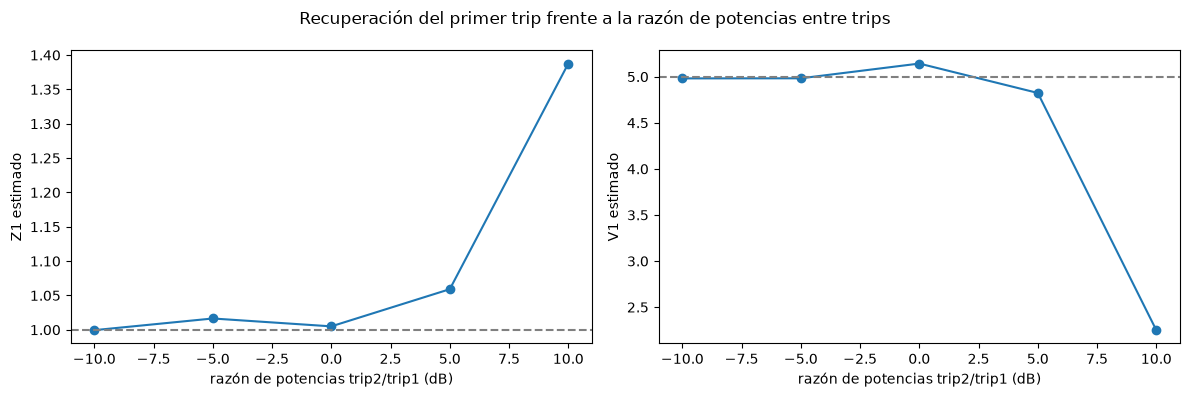

In [4]:
WAVELENGTH_M, PRT_S, M = 0.10, 1.0e-3, 64
NOISE_FLOOR = 0.05
POWER1, MEAN_V1, SIGMA_V1 = 1.0, 5.0, 1.5
MEAN_V2, SIGMA_V2 = -10.0, 1.5  # segundo trip: eco distinto, velocidad distinta


def recover_trip1(power2_ratio_db, rng):
    power2 = POWER1 * 10.0 ** (power2_ratio_db / 10.0)
    x1 = generate_signal_only(POWER1, MEAN_V1, SIGMA_V1, WAVELENGTH_M, PRT_S, M, rng)
    x2 = generate_signal_only(power2, MEAN_V2, SIGMA_V2, WAVELENGTH_M, PRT_S, M, rng)
    phi1 = rng.uniform(-np.pi, np.pi, size=M)  # fase del burst del pulso actual (primer trip)
    phi2 = rng.uniform(-np.pi, np.pi, size=M)  # fase del pulso anterior (segundo trip), independiente
    y = x1 * np.exp(1j * phi1) + x2 * np.exp(1j * phi2) + complex_gaussian(rng, NOISE_FLOOR, size=M)
    y_corr = y * np.exp(-1j * phi1)
    r0 = np.mean(np.abs(y_corr) ** 2)
    n_hat = noise_floor_estimate(y_corr)
    z1_hat = max(r0 - n_hat, 0.0)
    v1_hat = pulse_pair_velocity(y_corr, WAVELENGTH_M, PRT_S)
    return z1_hat, v1_hat


RATIO_DB_GRID = [-10.0, -5.0, 0.0, 5.0, 10.0]
N_TRIALS_RECOVERY = 500

z1_by_ratio, v1_by_ratio = [], []
for ratio_db in RATIO_DB_GRID:
    zs, vs = zip(*(recover_trip1(ratio_db, rng) for _ in range(N_TRIALS_RECOVERY)))
    z1_by_ratio.append(np.mean(zs)); v1_by_ratio.append(np.mean(vs))
    print(f"P2/P1={ratio_db:5.1f} dB  Z1_hat={z1_by_ratio[-1]:.4f} (verdadero {POWER1})  "
          f"V1_hat={v1_by_ratio[-1]:.3f} (verdadero {MEAN_V1})")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(RATIO_DB_GRID, z1_by_ratio, marker="o")
axes[0].axhline(POWER1, color="gray", linestyle="--")
axes[0].set_xlabel("razón de potencias trip2/trip1 (dB)"); axes[0].set_ylabel("Z1 estimado")
axes[1].plot(RATIO_DB_GRID, v1_by_ratio, marker="o")
axes[1].axhline(MEAN_V1, color="gray", linestyle="--")
axes[1].set_xlabel("razón de potencias trip2/trip1 (dB)"); axes[1].set_ylabel("V1 estimado")
plt.suptitle("Recuperación del primer trip frente a la razón de potencias entre trips")
plt.tight_layout()
plt.show()

checks.append(("Z1 y V1 se recuperan bien cuando el segundo trip es más débil (<= 0 dB): "
               "Z1 dentro de 15%, V1 dentro de 0.5 m/s",
               all(abs(z1_by_ratio[i] - POWER1) < 0.15 * POWER1 for i in range(3))
               and all(abs(v1_by_ratio[i] - MEAN_V1) < 0.5 for i in range(3))))
checks.append(("la degradación es medible y clara cuando el segundo trip domina (+10 dB): "
               "Z1 se desvía más del 30% de la verdad-terreno",
               abs(z1_by_ratio[-1] - POWER1) > 0.30 * POWER1))

## Fuera de alcance, declarado

- **SZ(8/64)**: página propia, diferida a Stage 2 por la propia
  `dealiasing-de-rango.md`.
- **Vía indirecta por staggered-PRT**: la página la menciona como
  información de paso ("permite identificar aunque no siempre separar"),
  no como un algoritmo de recuperación con criterio de aceptación propio en
  esta página.
- **Interacción con polarimetría alternante** (mitad de muestras por canal,
  peor separación estadística de los dos trips): nota de diseño a tener en
  cuenta al fijar el criterio de aceptación de una implementación real, no
  una cantidad numérica que este oráculo, con generadores de canal único,
  pueda ejercitar de forma independiente de lo que ya cubre `polarimetria-
  covarianzas.md`.

In [5]:
all_ok = True
for name, ok in checks:
    print(f"[{'OK' if ok else 'FALLO'}] {name}")
    all_ok = all_ok and ok

assert all_ok, "el oráculo de dealiasing de rango no pasa todas las comprobaciones — ver tabla arriba"
print("\nTodas las comprobaciones dentro de tolerancia.")

[OK] a SNR alta (15 dB) la clasificación es fiable (>= 95% en ambos casos)
[OK] la tasa de acierto degrada de forma monótona (no mejora) al bajar la SNR
[OK] Z1 y V1 se recuperan bien cuando el segundo trip es más débil (<= 0 dB): Z1 dentro de 15%, V1 dentro de 0.5 m/s
[OK] la degradación es medible y clara cuando el segundo trip domina (+10 dB): Z1 se desvía más del 30% de la verdad-terreno

Todas las comprobaciones dentro de tolerancia.
